In [1]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pyreadr # to read .rds files

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [2]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
Total_EN = 10

## Inputs

In [175]:
CO2_cases  = ("AMB", "ELE" )

fnames={}
case_id_suffix = ["_C","_RD","_ECA"]
# for Vmax
#case_id_suffix = ["_C","_ECA"]
#case_id_suffix = ["_C","_RD"]
case_id_suffix = ["_RD",]
#case_id_suffix = ["_ECA",]

fns = ["RD","ECA"]
fns = ["RD",]
       
case_id_base = "FACE_r240912_enBaseRate"
case_id_base = "FACE_r240913_enVmax"
#case_id_base = "FACE_r240914a_enVmax"
#case_id_base = "FACE_r240914b_enVmax"
#case_id_base = "FACE_r240914c_enVmax"
#case_id_base = "FACE_r240914d_enVmax"
#case_id_base = "FACE_r240914e_enVmax"
case_id_base = "FACE_r241011_enStoreOvrflw"
#case_id_base = "FACE_r241015_ModL2FR_enStoreOvrflw"
#case_id_base = "FACE_r241018_ModL2FRcn_enStoreOvrflw"
#case_id_base = "FACE_r241021_ModL2FRcn_enStoreOvrflw"
case_id_base = "FACE_r241030_Sz_enStoreOvrflw"

co2_case = CO2_cases[0] # 0: amb ; 1 :ele

case_ids = [f"{case_id_base}{suf}" for suf in case_id_suffix]

sites= ("US-ORN", "US-DUK")
sites= ("US-DUK",)
#sites= ("US-ORN",)

dict_model_sites= {"ORNL" : "US-ORN", "DUKE" : "US-DUK"}
#run_case = "eCO2"
run_CO2_case = {"AMB":"aCO2", "ELE":"eCO2"}

#run_case = "aCO2"
#run_case = "eCO2"
run_cases = ["aCO2", "eCO2"]
#run_cases = ["aCO2",] #"eCO2"]


for en_idx in range(Total_EN):
    for site in sites:
        for case_id in case_ids:
            for run_case in run_cases:
                if case_id.split('_')[-1] == "C":
                    mod_case_id_C = "_".join(case_id.split('_')[:-1])
                    fnames[f"{case_id}_{site}_{run_case}_en{en_idx+1}"] = f"{path_in}{mod_case_id_C}_processed/{mod_case_id_C}_{site}_{run_case}_{'g{:05d}'.format(en_idx+1)}.nc"
                else:
                    fnames[f"{case_id}_{site}_{run_case}_en{en_idx+1}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}_{'g{:05d}'.format(en_idx+1)}.nc"
    

In [176]:
fnames

{'FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en1': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00001.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_en1': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_g00001.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en2': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00002.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_en2': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_g00002.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en3': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FA

## Check for failed runs (it will take time to run)

In [177]:
# Check for failed runs
failed_keys = []
for site in sites:
    print (f"\n Lets do {site}  .... \n")
    for idx, key in enumerate(fnames.keys()):
        try:
            if site in key: 
                print (key,fnames[key], ':', xr.open_mfdataset(fnames[key]).FATES_NCOHORTS.time.shape) 
        except:
            print (key, ':', "FAIL")
            failed_keys.append(key)


 Lets do US-DUK  .... 

FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en1 /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00001.nc : (4380,)
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_en1 /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_g00001.nc : (4380,)
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en2 /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00002.nc : (4380,)
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_en2 /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_g00002.nc : (4380,)
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en3 /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_

In [178]:
print(f"list of failed cases: {failed_keys}")

list of failed cases: []


In [179]:
"enStoreOvrflw" in case_id_base

True

In [180]:
fn = fns[0]
params_fname = "vmax_r240615b_RD.csv"
params_fname = "vmax_r240620_RD.csv"
params_fname = "vmax_r240620_ECA.csv"
params_fname = "vmax_r240701_ECA.csv"
params_fname = "vmax_r240701_ECA.xlsx"
params_fname = "vmax_r240703_ECA"
params_fname = "vmax_r240902_RD" 
#params_fname = "vcmax_r240802"# 37 ensembles
#params_fname = "baserate_240830" # 42 ensembles
params_fname = f"vmax_r240913_{fn}" # 37 ensembles
#params_fname = "vmax_r240913_RD" # 37 ensembles
#params_fname = "vmax_r240728_ECA" # 31 ensembles
#params_fname = "baserate_240912" # 21 ensembles

if "enStoreOvrflw" in case_id_base:
    params_fname = f"StoreOvrflw_r241010_{fn}" # 10 ensembles'
    if case_id_base == "FACE_r241030_Sz_enStoreOvrflw":
        params_fname = f"StoreOvrflw_r241101_{fn}" # 10 ensembles


try:
    #df_vmax_values = pd.read_csv(f"{path_in}{case_id}_processed/{params_fname}.csv")
    #df_vmax_values = pd.read_excel(f"{path_in}{case_id}_processed/{params_fname}.xlsx")
    df_vmax_values = pd.read_excel(f"{path_in}Ensemble_vals/{params_fname}.xlsx")
    print (df_vmax_values)
    #list_legend = df_vmax_values['fates_cnp_vmax_nh4'].values
    list_legend = df_vmax_values['Store_ovrflw'].values
    #list_legend = df_vmax_values['vcmax_vals'].values
    #list_legend = df_vmax_values['non_leaf'].values
except:
    path_tmp = f"{path_in}Ensemble_vals/{params_fname}.xlsx"
    print (".......\nParams file not read | Try again\n.......")
    print (path_tmp)
    pass


# Convert to list of formatted strings
#formatted_list = [f"NH4_{nh4:.01e}_P_{p:.01e}" for nh4, p in zip(df_vmax_values['fates_cnp_vmax_nh4'], df_vmax_values['fates_cnp_vmax_p'])]
#formatted_list = [f"Ovrflw_{so}" for so in zip(df_vmax_values['Store_ovrflw'])]
formatted_list = [f"Ovrflw_{so}" for so in df_vmax_values['Store_ovrflw']]
#formatted_list = [f"Leaf_{nh4:.01e}_NonLeaf_{p:.01e}" for nh4, p in zip(df_vmax_values['leaf'], df_vmax_values['non_leaf'])]
#formatted_list

   RD  Store_ovrflw
0   1          0.00
1   2          0.25
2   3          0.50
3   4          0.62
4   5          0.75
5   6          0.88
6   7          1.00
7   8          2.00
8   9          3.00
9  10          5.00


## read the data


In [181]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    print (key)
    #ds[key] = xr.open_mfdataset(fnames[key],decode_times=True)
    # random errors : ignore following keys
    if key not in failed_keys:
        ds[key] = xr.open_mfdataset(fnames[key])
        print (fnames[key])


FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en1
/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00001.nc
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_en1
/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_g00001.nc
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en2
/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00002.nc
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_en2
/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_g00002.nc
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_en3
/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US

In [182]:
# How long do you want the simulation plots?
max_r_years = 13

output_freq = "daily" # spins
multiply_factor = 365 # 365 for daily output; else 1 for yearly



In [183]:
ds[key]

<xarray.Dataset>
Dimensions:                           (fates_levscag: 91, fates_levscpf: 13, fates_levcapf: 2, fates_levcnlf: 60, fates_levcnlfpf: 60, fates_levscagpf: 91, fates_levagepft: 7, fates_levelpft: 3, fates_levelcwd: 12, fates_levelage: 21, fates_levagefuel: 42, fates_levcdsc: 26, fates_levcdpf: 26, time: 4380, hist_interval: 2, lndgrid: 1, levgrnd: 15, levlak: 10, fates_levscls: 13, fates_levage: 7, fates_levheight: 6, fates_levpft: 1, fates_levcan: 2, fates_levelem: 3, levsoi: 10, fates_levfuel: 6, fates_levcacls: 2, levdcmp: 15, ltype: 9, natpft: 15)
Coordinates: (12/13)
  * time                              (time) object 1996-01-01 00:00:00 ... 2...
  * levgrnd                           (levgrnd) float64 0.007101 ... 35.18
  * levlak                            (levlak) float64 0.05 0.6 ... 34.33 44.78
  * fates_levscls                     (fates_levscls) float64 0.0 ... 9.969e+36
  * fates_levage                      (fates_levage) float64 0.0 1.0 ... 50.0
  * fates_levheight                   (fates_levheight) float64 0.0 0.1 ... 10.0
    ...                                ...
  * fates_levcan                      (fates_levcan) int32 1 2
  * fates_levelem                     (fates_levelem) int32 1 4 5
  * levsoi                            (levsoi) float64 0.007101 ... 2.865
  * fates_levfuel                     (fates_levfuel) int32 1 2 3 4 5 6
  * fates_levcacls                    (fates_levcacls) float64 0.0 5.0
  * levdcmp                           (levdcmp) float64 0.007101 ... 35.18
Dimensions without coordinates: fates_levscag, fates_levscpf, fates_levcapf, fates_levcnlf, fates_levcnlfpf, fates_levscagpf, fates_levagepft, fates_levelpft, fates_levelcwd, fates_levelage, fates_levagefuel, fates_levcdsc, fates_levcdpf, hist_interval, lndgrid, ltype, natpft
Data variables: (12/662)
    fates_scmap_levscag               (fates_levscag) int32 dask.array<chunksize=(91,), meta=np.ndarray>
    fates_agmap_levscag               (fates_levscag) int32 dask.array<chunksize=(91,), meta=np.ndarray>
    fates_pftmap_levscpf              (fates_levscpf) int32 dask.array<chunksize=(13,), meta=np.ndarray>
    fates_scmap_levscpf               (fates_levscpf) int32 dask.array<chunksize=(13,), meta=np.ndarray>
    fates_pftmap_levcapf              (fates_levcapf) int32 dask.array<chunksize=(2,), meta=np.ndarray>
    fates_camap_levcapf               (fates_levcapf) int32 dask.array<chunksize=(2,), meta=np.ndarray>
    ...                                ...
    WTGQ                              (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZBOT                              (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZWT                               (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZWT_CH4_UNSAT                     (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZWT_PERCH                         (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    o2_decomp_depth_unsat             (time, levgrnd, lndgrid) float32 dask.array<chunksize=(4380, 15, 1), meta=np.ndarray>

## One variable at a time

In [420]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_EXCESS_RESP",
        #"FATES_L2FR",
        #"FATES_NCOHORTS",
        #"TLAI", 
        #"FATES_AUTORESP",
        #"FATES_NPP_Minus_EXCESS_RESP",
        #"CUE",
        #"FATES_NDEMAND",
        #"FATES_STRUCTC",
        #"FATES_SAPWOODC",
        #"FATES_LEAFC",
        "FATES_FROOTC",
        #"FATES_VEGC",
        #"FATES_VEGC_ABOVEGROUND",
        #"FATES_NH4UPTAKE",
        #"FATES_STOREC",
        #"FATES_STOREC_TF",
        #"FATES_STOREN_TF",
        #"SMINN",
        #"SMINN_TO_PLANT",
        #"NET_NMIN",
        #"NET_NMIN",
        #"FATES_STOREP_TF",
        #"NET_NMIN",
        #"TOTSOMC",
        #"TOTSOMN",
        #"FATES_CROOT_ALLOC",
        #"FATES_FROOT_ALLOC",
        #"FATES_LEAF_ALLOC",
        #"FATES_SEED_ALLOC",
        #"FATES_STEM_ALLOC",
        #"NPP_sum_Alloc",
        #"FATES_NPP_Minus_NPP_sum_Alloc",
        #"FATES_NPP_Minus_EXCESS_RESP_Minus_NPP_sum_Alloc",
       )
var = vars[0]

In [421]:
var

'FATES_FROOTC'

In [422]:
def read_nc_data (site, case_id, run_case):
    data = {}
    for idx, key in enumerate(ds.keys()):
        for var in vars:
            #print(var)
            if (site in key) and (run_case in key) and (case_id in key):
                li = int(key.split("_")[-1][2:])-1
            #if True:data[f"{key}"] = (ds[site][key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1)  - ds[site][key]["FATES_EXCESS_RESP"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                if "FATES_NPP_Minus_EXCESS_RESP" in vars:
                    #text_units = ds[key]["FATES_NPP"].attrs["units"]
                    data[f"{formatted_list[li]}"] = (ds[key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1) - ds[key]["FATES_EXCESS_RESP"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                    var = "FATES_NPP"
                    text_add_var = "_Minus_EXCESS_RESP"
                    text_units = "gC m-2 y-1"
                elif "FATES_NPP" in vars:
                    #text_units = ds[key]["FATES_NPP"].attrs["units"]
                    data[f"{formatted_list[li]}"] = (ds[key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                    var = "FATES_NPP"
                    text_add_var = ""
                    text_units = "gC m-2 y-1"
                elif "FATES_NCOHORTS" in vars:
                    ds[key][var].attrs["units"] = "#"
                    data[f"{formatted_list[li]}"] = ds[key][var].resample(time='A').sum().values.reshape(-1)
                    text_add_var= ''
                elif "CUE" in vars:
                    text_units = ds[key]["FATES_NPP"].attrs["units"]
                    data[f"{formatted_list[li]}"] = (ds[key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1) - ds[key]["FATES_EXCESS_RESP"].resample(time='A').sum().values.reshape(-1))/ds[key]["FATES_GPP"].resample(time='A').sum().values.reshape(-1)
                    var = "FATES_NPP"
                    text_add_var = "_CUE=GPPdivNPPExResp"
                elif "FATES_CROOT_ALLOC" in vars:
                    data[f"{formatted_list[li]}"] = ds[key][var].resample(time='A').sum().values.reshape(-1)*1000*24*60*60
                    text_units = "gC m-2 y-1"
                    text_add_var = ''
                elif "FATES_FROOT_ALLOC" in vars:
                    data[f"{formatted_list[li]}"] = ds[key][var].resample(time='A').sum().values.reshape(-1)*1000*24*60*60
                    text_units = "gC m-2 y-1"
                    text_add_var = ''
                elif "FATES_LEAF_ALLOC" in vars:
                    data[f"{formatted_list[li]}"] = ds[key][var].resample(time='A').sum().values.reshape(-1)*1000*24*60*60
                    text_units = "gC m-2 y-1"
                    text_add_var = ''
                elif "FATES_SEED_ALLOC" in vars:
                    data[f"{formatted_list[li]}"] = ds[key][var].resample(time='A').sum().values.reshape(-1)*1000*24*60*60
                    text_units = "gC m-2 y-1"
                    text_add_var = ''
                elif "FATES_STEM_ALLOC" in vars:
                    data[f"{formatted_list[li]}"] = ds[key][var].resample(time='A').sum().values.reshape(-1)*1000*24*60*60
                    text_units = "gC m-2 y-1"
                    text_add_var = ''
                elif "NPP_sum_Alloc" in vars:
                    data[f"{formatted_list[li]}"] = (ds[key]["FATES_CROOT_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_FROOT_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_LEAF_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_SEED_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_STEM_ALLOC"].resample(time='A').sum().values.reshape(-1)
                                                    )*1000*24*60*60
                    text_units = "gC m-2 y-1"
                    var = "NPP Sum Alloc"
                    text_add_var = ''
                    
                elif "FATES_NPP_Minus_NPP_sum_Alloc" in vars:
                    #text_units = ds[key]["FATES_NPP"].attrs["units"]
                    data[f"{formatted_list[li]}"] = (ds[key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1) - 
                                                     (ds[key]["FATES_CROOT_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_FROOT_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_LEAF_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_SEED_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_STEM_ALLOC"].resample(time='A').sum().values.reshape(-1)
                                                     )
                                                    )*1000*24*60*60
                    var = "FATES_NPP_Minus_NPP_sum_Alloc"
                    text_add_var = ""
                    text_units = "gC m-2 y-1"
                    
                elif "FATES_NPP_Minus_EXCESS_RESP_Minus_NPP_sum_Alloc" in vars:
                    #text_units = ds[key]["FATES_NPP"].attrs["units"]
                    data[f"{formatted_list[li]}"] = (ds[key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1) -
                                                     ds[key]["FATES_EXCESS_RESP"].resample(time='A').sum().values.reshape(-1) -
                                                     (ds[key]["FATES_CROOT_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_FROOT_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_LEAF_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_SEED_ALLOC"].resample(time='A').sum().values.reshape(-1) +
                                                     ds[key]["FATES_STEM_ALLOC"].resample(time='A').sum().values.reshape(-1)
                                                     )
                                                    )*1000*24*60*60
                    var = "FATES_NPP_Minus_NPP_sum_Alloc"
                    text_add_var = ""
                    text_units = "gC m-2 y-1"
                else:
                    data[f"{formatted_list[li]}"] = ds[key][var].resample(time='A').mean().values.reshape(-1)
                    text_add_var = ''
                    print (ds[key]["FATES_NPP"].attrs["units"])
                ktmp = key
                #li+=1

    try: 
        if var == "CUE":
            var = "FATES_NPP"  
    except:
        pass
    var = "FATES_NPP"

    #time = np.arange(0,len(ds[ktmp][var].values.reshape(-1)))
    #print (ktmp,var)
    time = ds[ktmp][var].resample(time='A').sum().time
    #time = ds[ktmp][var].time

    data['date'] = time
    df = pd.DataFrame(data)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna( how="all", inplace=True)
    ts_year = []
    for d in df["date"]:
        ts_year.append(pd.to_datetime(d.isoformat()).year)
    df["Year"] = ts_year
    df = df.drop(columns=['date'])
    return df,text_add_var

In [423]:
key

'FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2_en10'

In [424]:
dict_df = {}
for case_id in case_ids:
    for site in sites:
        for run_case in run_cases:
            print (case_id, site, run_case)
            try:
                dict_df[f"{case_id}_{site}_{run_case}"] = read_nc_data (site, case_id,run_case)[0]
                text_add_var = read_nc_data (site, case_id,run_case)[1]
            except:
                print ("fail")
                pass


FACE_r241030_Sz_enStoreOvrflw_RD US-DUK aCO2
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
FACE_r241030_Sz_enStoreOvrflw_RD US-DUK eCO2
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1
kg m-2 s-1


In [425]:
i =0 
for k in dict_df.keys():
    i+=1
    print (k,i)



FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2 1
FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2 2


In [426]:
dict_df

{'FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2':     Ovrflw_0.0  Ovrflw_0.25  Ovrflw_0.5  Ovrflw_0.62  Ovrflw_0.75  \
 0     0.102591     0.060235    0.060591     0.060573     0.060530   
 1     0.103088     0.059333    0.061089     0.061075     0.061035   
 2     0.103505     0.056241    0.061507     0.061498     0.061461   
 3     0.103947     0.053285    0.060141     0.061934     0.061916   
 4     0.104427     0.050095    0.054512     0.058520     0.062132   
 5     0.104970     0.048756    0.053807     0.055606     0.058924   
 6     0.105232     0.043471    0.050530     0.053034     0.054554   
 7     0.105821     0.034316    0.046797     0.050004     0.052435   
 8     0.106429     0.035434    0.038977     0.047892     0.050687   
 9     0.106908     0.033896    0.029462     0.036868     0.046967   
 10    0.107341     0.033546    0.030313     0.030712     0.038220   
 11    0.107457     0.028000    0.028449     0.022655     0.027994   
 
     Ovrflw_0.88  Ovrflw_1.0  Ovrflw_2.0

In [427]:
print (k)
dict_df[k.replace('eCO2', 'eResponse')] = dict_df[k] - dict_df[k.replace('eCO2', 'aCO2')]
dict_df[k.replace('eCO2', 'eResponse')] ['Year'] = dict_df[k]['Year'] 

FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_eCO2


### response

FATES_FROOTC_US-DUK_RD_AMB_FACE_r241030_Sz_enStoreOvrflw_RD_line_plot.html


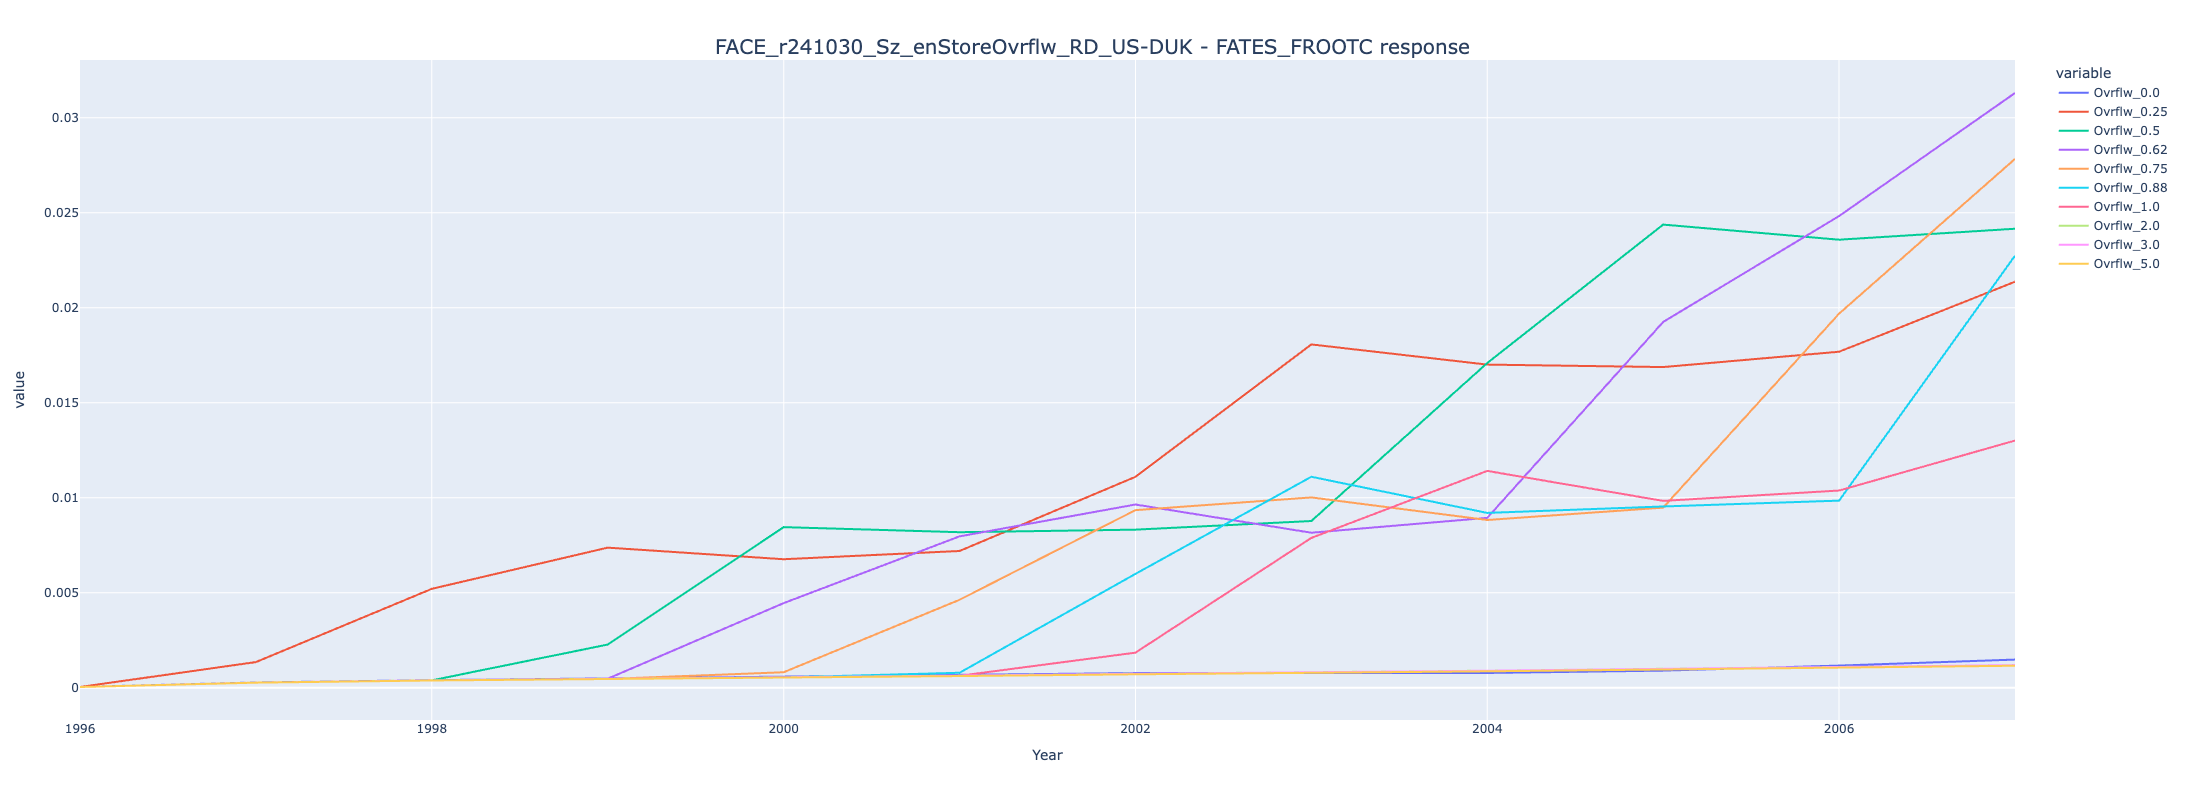

In [428]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
df_tmp = dict_df[k.replace('eCO2', 'eResponse')] 

#df_tmp = dict_df[site][var].copy(deep=True)
if var == "FATES_NPP_Minus_EXCESS_RESP":
    var_tmp = "NPP"
elif var == "FATES_NPP":
    var_tmp = "NPP"
else:
    var_tmp = var
    
fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
  hover_data={"Year": "%Y"},)
kt= k.replace("_eCO2","")
# Update layout with a custom title
fig.update_layout(
title={
    'text': f" {kt} - {var} response ",
    'y': 0.95,  # Position title slightly above the plot
    'x': 0.5,  # Center the title horizontally
    'xanchor': 'center',
    'yanchor': 'top'
},
title_font=dict(size=20),  # Adjust the font size of the title
width=1200, height=800  # Adjust width and height as needed
)
# Save the plot as an HTML file
path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
#fig.write_html(f"{path_html_save}/{var}_{site}_{fn}_{co2_case}_minC{min_checks}_line_plot.html")
print (f"{var}_{site}_{fn}_{co2_case}_{case_id}_line_plot.html")
# Show the plot
fig.show()


FATES_FROOTC_US-DUK_RD_AMB_FACE_r241030_Sz_enStoreOvrflw_RD_line_plot.html


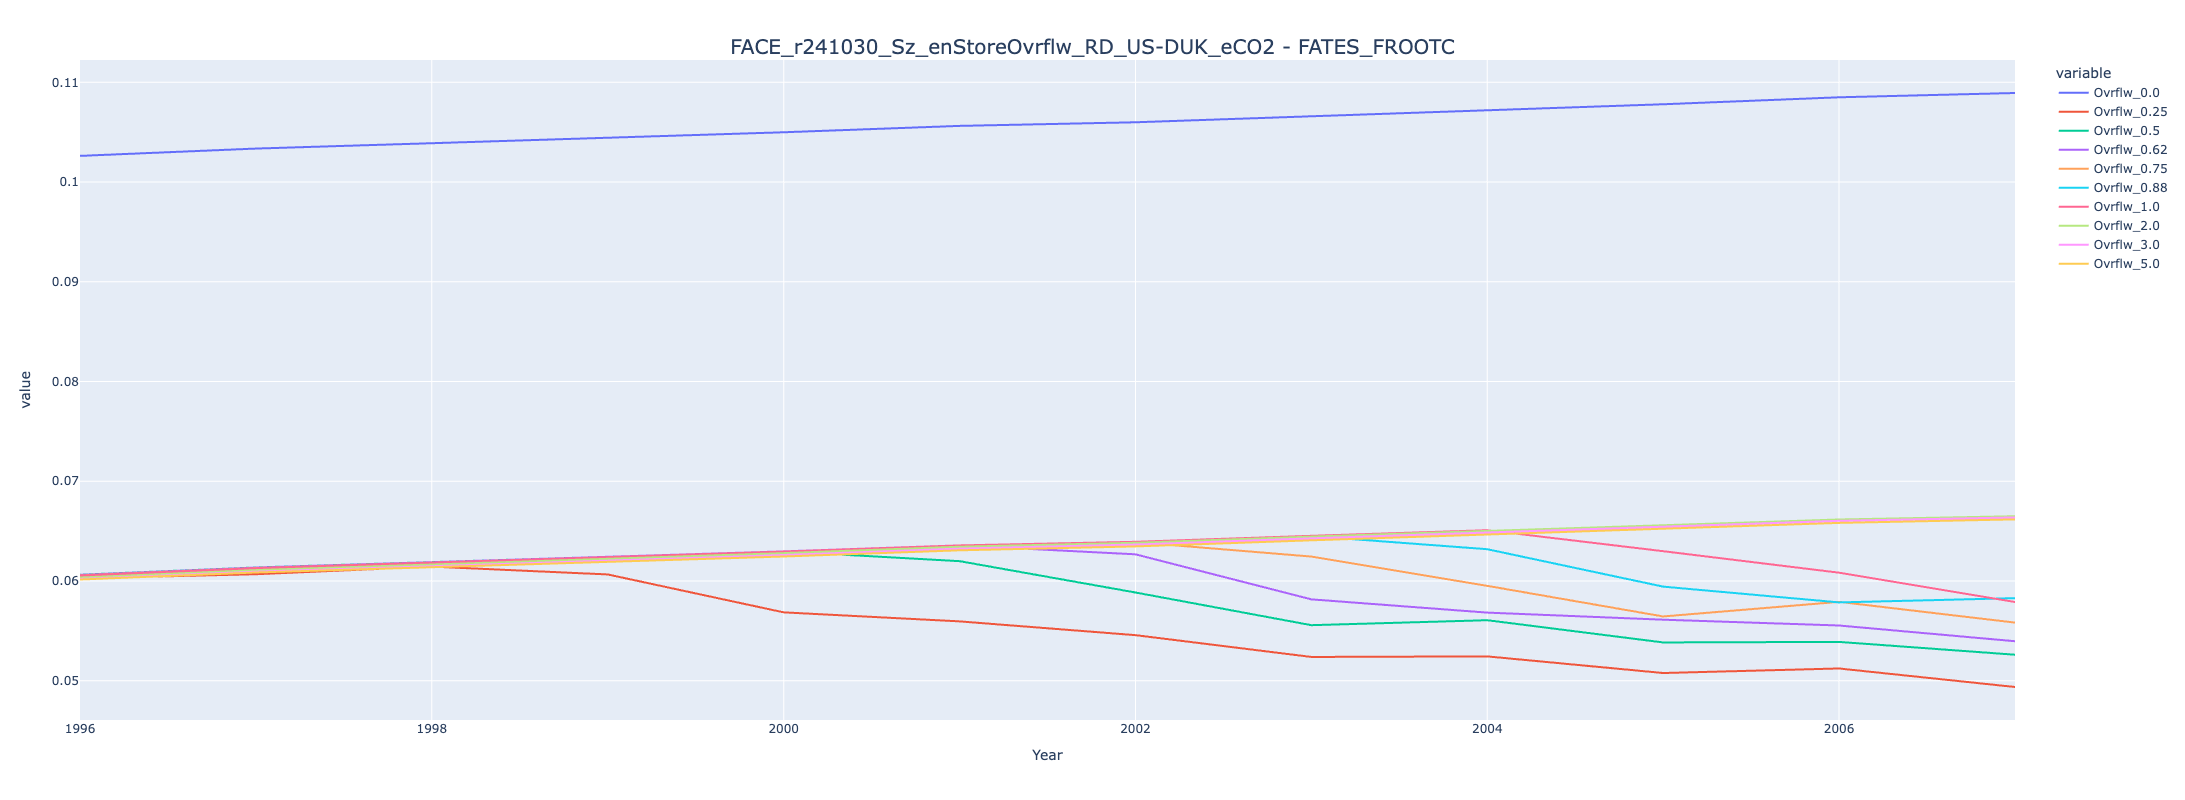

In [429]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
df_tmp = dict_df[k] 

#df_tmp = dict_df[site][var].copy(deep=True)
if var == "FATES_NPP_Minus_EXCESS_RESP":
    var_tmp = "NPP"
elif var == "FATES_NPP":
    var_tmp = "NPP"
else:
    var_tmp = var
    
fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
  hover_data={"Year": "%Y"},)
kt= k
# Update layout with a custom title
fig.update_layout(
title={
    'text': f" {kt} - {var}  ",
    'y': 0.95,  # Position title slightly above the plot
    'x': 0.5,  # Center the title horizontally
    'xanchor': 'center',
    'yanchor': 'top'
},
title_font=dict(size=20),  # Adjust the font size of the title
width=1200, height=800  # Adjust width and height as needed
)
# Save the plot as an HTML file
path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
#fig.write_html(f"{path_html_save}/{var}_{site}_{fn}_{co2_case}_minC{min_checks}_line_plot.html")
print (f"{var}_{site}_{fn}_{co2_case}_{case_id}_line_plot.html")
# Show the plot
fig.show()


FATES_FROOTC_US-DUK_RD_AMB_FACE_r241030_Sz_enStoreOvrflw_RD_line_plot.html


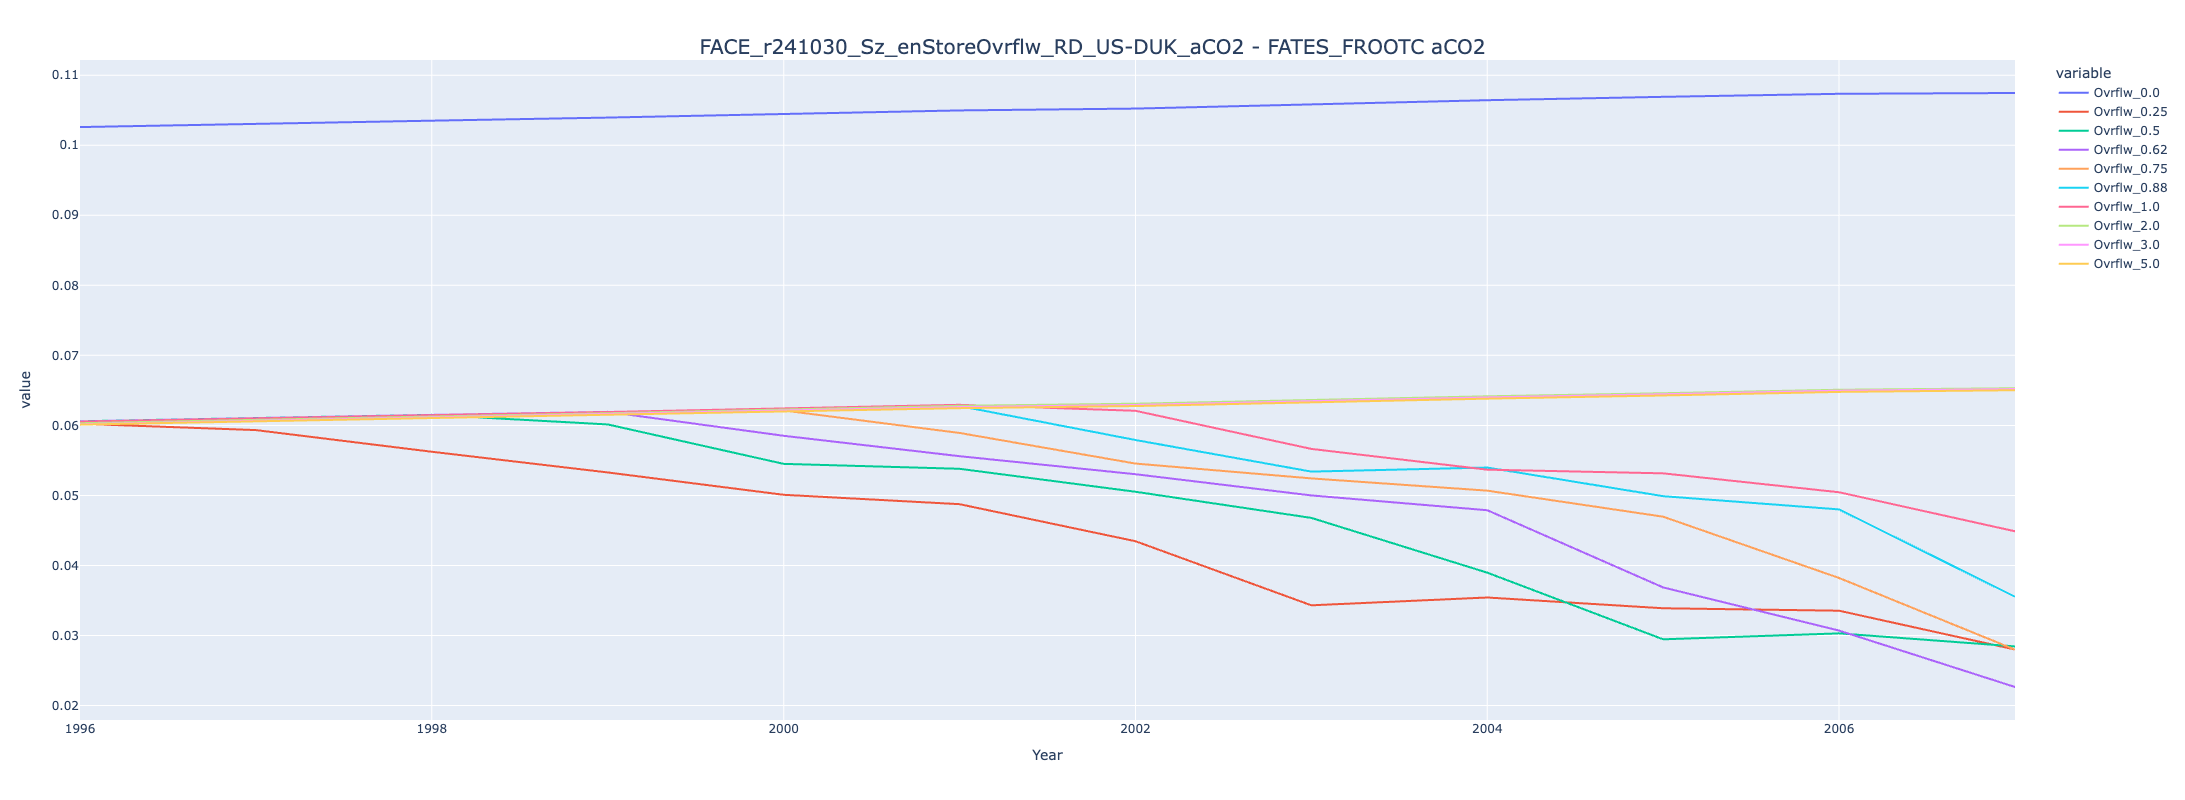

In [430]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
df_tmp = dict_df[k.replace('eCO2', 'aCO2')] 

#df_tmp = dict_df[site][var].copy(deep=True)
if var == "FATES_NPP_Minus_EXCESS_RESP":
    var_tmp = "NPP"
elif var == "FATES_NPP":
    var_tmp = "NPP"
else:
    var_tmp = var
    
fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
  hover_data={"Year": "%Y"},)
kt= k.replace("_eCO2","_aCO2")
# Update layout with a custom title
fig.update_layout(
title={
    'text': f" {kt} - {var} aCO2 ",
    'y': 0.95,  # Position title slightly above the plot
    'x': 0.5,  # Center the title horizontally
    'xanchor': 'center',
    'yanchor': 'top'
},
title_font=dict(size=20),  # Adjust the font size of the title
width=1200, height=800  # Adjust width and height as needed
)
# Save the plot as an HTML file
path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
#fig.write_html(f"{path_html_save}/{var}_{site}_{fn}_{co2_case}_minC{min_checks}_line_plot.html")
print (f"{var}_{site}_{fn}_{co2_case}_{case_id}_line_plot.html")
# Show the plot
fig.show()
